In [161]:
import socket
import sys
import os
import time
import importlib
from pathlib import Path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../../src"))) #use this to be able to import local packages
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src"))) #use this to be able to import local packages
import numpy as np
import pandas as pd
import pickle
import pyarrow.parquet as pq
import utils.openkarst_network
from utils.openkarst_network import OpenKarstNetwork as OKN
importlib.reload(utils.openkarst_network)
import utils.conduits
importlib.reload(utils.conduits)
from utils.conduits import *
import utils.network_metrics
importlib.reload(utils.network_metrics)
from utils.network_metrics import *
from utils.common import load_yaml, print_verbose, load_pickle
import openkarst
importlib.reload(openkarst)

from openkarst.visualization.openkarst_viewer import launch_openkarst_viewer
import utils.spring as spring
importlib.reload(utils.spring)
import utils.spring as spring
import seaborn as sns
import matplotlib.pyplot as plt


In [88]:
def load_data(results_dir):
    results = np.load(f'{results_dir}/results.npz')
    input_data = load_pickle(f'{results_dir}/input_data.pkl')


    obs_df = pd.read_csv(f'{results_dir}/observation_data.csv')
    return results, input_data, obs_df

In [189]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16 

In [ ]:
    'Anastomotic density 7, pressurized' : 'anastomotic_density_7/fully_pressurized/no_reservoir',
    'Anastomotic density 7, partially pressurized' : 'anastomotic_density_7/partially_pressurized/no_reservoir',
    'Anastomotic density 7, unpressurized' : 'anastomotic_density_7/unpressurized/no_reservoir',

In [389]:
path_dir = {
    # 'Anastomotic, pressurized' : 'high_anastomotic/d=0.1/no_reservoir',
    # 'Anastomotic, unpressurized' : 'high_anastomotic/d=1.0/no_reservoir',
    # 'Anastomotic, partially pressurized' : 'high_anastomotic/d=0.5/no_reservoir',
    # 'Anastomotic 2, pressurized' : 'anastomotic_2/d=0.1/no_reservoir',
    # 'Anastomotic 2, partially pressurized' : 'anastomotic_2/d=0.5/no_reservoir',
    # 'Anastomotic 2, unpressurized' : 'anastomotic_2/d=1.0/no_reservoir',

    # 'Low anastomotic, pressurized' : 'low_anastomotic/d=0.1/no_reservoir',
    # 'Low anastomotic, partially pressurized' : 'low_anastomotic/d=0.5/no_reservoir',
    # 'Low anastomotic, unpressurized' : 'low_anastomotic/d=1.0/no_reservoir',

    # # 'Branching network, pressurized' : 'branching_straight_network/d=0.1/no_reservoir',
    # # 'Branching network partially pressurized' : 'branching_straight_network/d=0.5/no_reservoir',
    # # 'Branching network unpressurized' : 'branching_straight_network/d=1.0/no_reservoir',

    # 'Single conduit, pressurized' : '1D_conduit/d=0.1/no_reservoir',
    # 'Single conduit, partially pressurized' : '1D_conduit/d=0.5/no_reservoir',
    # 'Single conduit, unpressurized' : '1D_conduit/d=1.0/no_reservoir',
        'Anastomotic, pressurized' : 'high_anastomotic/fully_pressurized/no_reservoir',
    'Anastomotic, unpressurized' : 'high_anastomotic/unpressurized/no_reservoir',
    'Anastomotic, partially pressurized' : 'high_anastomotic/partially_pressurized/no_reservoir',
    'Anastomotic 2, pressurized' : 'anastomotic_2/fully_pressurized/no_reservoir',
    'Anastomotic 2, partially pressurized' : 'anastomotic_2/partially_pressurized/no_reservoir',
    'Anastomotic 2, unpressurized' : 'anastomotic_2/unpressurized/no_reservoir',

 'Anastomotic density 1, pressurized' : 'anastomotic_density_1/fully_pressurized/no_reservoir',
    'Anastomotic density 1, partially pressurized' : 'anastomotic_density_1/partially_pressurized/no_reservoir',
    'Anastomotic density 1, unpressurized' : 'anastomotic_density_1/unpressurized/no_reservoir',
        'Anastomotic density 1.5, pressurized' : 'anastomotic_density_1.5/fully_pressurized/no_reservoir',
    'Anastomotic density 1.5, partially pressurized' : 'anastomotic_density_1.5/partially_pressurized/no_reservoir',
    'Anastomotic density 1.5, unpressurized' : 'anastomotic_density_1.5/unpressurized/no_reservoir',

        'Anastomotic density 2, pressurized' : 'anastomotic_density_2/fully_pressurized/no_reservoir',
    'Anastomotic density 2, partially pressurized' : 'anastomotic_density_2/partially_pressurized/no_reservoir',
    'Anastomotic density 2, unpressurized' : 'anastomotic_density_2/unpressurized/no_reservoir',
    'Anastomotic density 2.5, pressurized' : 'anastomotic_density_2.5/fully_pressurized/no_reservoir',
    'Anastomotic density 2.5, partially pressurized' : 'anastomotic_density_2.5/partially_pressurized/no_reservoir',
    'Anastomotic density 2.5, unpressurized' : 'anastomotic_density_2.5/unpressurized/no_reservoir',
        'Anastomotic density 3, pressurized' : 'anastomotic_density_3/fully_pressurized/no_reservoir',
    'Anastomotic density 3, partially pressurized' : 'anastomotic_density_3/partially_pressurized/no_reservoir',
    'Anastomotic density 3, unpressurized' : 'anastomotic_density_3/unpressurized/no_reservoir',
        'Anastomotic density 5, pressurized' : 'anastomotic_density_5/fully_pressurized/no_reservoir',
    'Anastomotic density 5, partially pressurized' : 'anastomotic_density_5/partially_pressurized/no_reservoir',
    'Anastomotic density 5, unpressurized' : 'anastomotic_density_5/unpressurized/no_reservoir',

        'Anastomotic density 6, pressurized' : 'anastomotic_density_6/fully_pressurized/no_reservoir',
    'Anastomotic density 6, partially pressurized' : 'anastomotic_density_6/partially_pressurized/no_reservoir',
    'Anastomotic density 6, unpressurized' : 'anastomotic_density_6/unpressurized/no_reservoir',
        'Anastomotic density 7, pressurized' : 'anastomotic_density_7/fully_pressurized/no_reservoir',
    'Anastomotic density 7, partially pressurized' : 'anastomotic_density_7/partially_pressurized/no_reservoir',
    'Anastomotic density 7, unpressurized' : 'anastomotic_density_7/unpressurized/no_reservoir',
    'Low anastomotic, pressurized' : 'low_anastomotic/fully_pressurized/no_reservoir',
    'Low anastomotic, partially pressurized' : 'low_anastomotic/partially_pressurized/no_reservoir',
    'Low anastomotic, unpressurized' : 'low_anastomotic/unpressurized/no_reservoir',

    'Branching network, pressurized' : 'branching_straight_network/fully_pressurized/no_reservoir',
    'Branching network, partially pressurized' : 'branching_straight_network/partially_pressurized/no_reservoir',
    'Branching network, unpressurized' : 'branching_straight_network/unpressurized/no_reservoir',

    'Single conduit, pressurized' : '1D_conduit/fully_pressurized/no_reservoir',
    'Single conduit, partially pressurized' : '1D_conduit/partially_pressurized/no_reservoir',
    'Single conduit, unpressurized' : '1D_conduit/unpressurized/no_reservoir',

}

results_dir = {}
network_metrics = pd.DataFrame(columns = ['run', 'alpha', 'beta', 'tortuosity', 'orientation_entropy', 'k_mean', 'Q_peak', 'V_spring/V_R', 'slope_recession'])

for name, path in path_dir.items():
    results, input_data, obs_df = load_data(path)
    results_dir[name] = {
        'results' : results,
        'input_data' : input_data,
        'obs_df' : obs_df
    }
    if 'pulse_only' in path:
        results_dir[name]['baseflow'] = 0
    else:
        results_dir[name]['baseflow'] = 0.02
    reduced_nodes, reduced_edges, reduced_graph = fully_reduce_graph(input_data['nodes'], input_data['edges'])
    try:
        alpha = alpha_index(reduced_nodes, reduced_edges)
    except ZeroDivisionError:
        alpha = 0
    beta = beta_index(reduced_nodes, reduced_edges)
    T = tortuosity(input_data['nodes'], input_data['edges'])
    _, _, H_0 = orientation_entropy(input_data['nodes'], input_data['edges'])
    k_mean = pd.DataFrame(reduced_graph.degree())[1].mean()
    results_dir[name]['network_metrics'] = {
        'alpha' : alpha,
        'beta' : beta,
        'tortuosity' : T,
        'orientation_entropy' : H_0,
        'k_mean' : k_mean
    }
    network_metrics.loc[len(network_metrics)] = {
        'run': name,
        'alpha': alpha,
        'beta': beta,
        'tortuosity': T,
        'orientation_entropy': H_0,
        'k_mean': k_mean
    }
network_metrics['hydraulic_regime'] = network_metrics['run'].apply(lambda x: x.split(', ')[-1])
network_metrics['network'] = network_metrics['run'].apply(lambda x: x.split(', ')[0])

71 123
71 123
71 123
57 92
57 92
57 92
35 51
35 51
35 51
29 39
29 39
29 39
30 42
30 42
30 42
37 54
37 54
37 54
43 62
43 62
43 62
38 52
38 52
38 52
29 39
29 39
29 39
39 57
39 57
39 57
6 5
6 5
6 5
7 6
7 6
7 6
2 1
2 1
2 1


<Axes: xlabel='time', ylabel='connected_net_flowrate'>

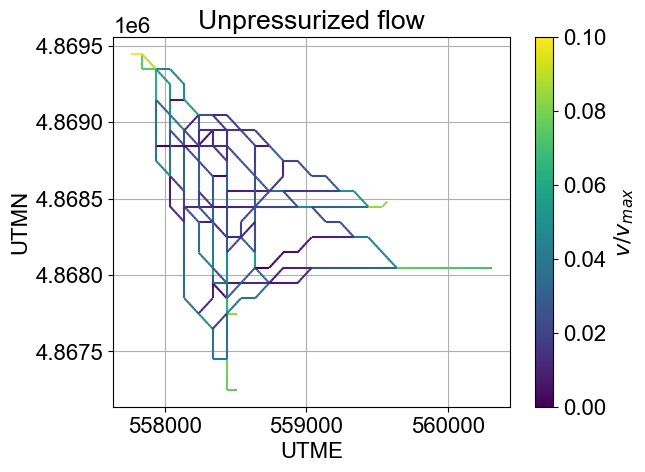

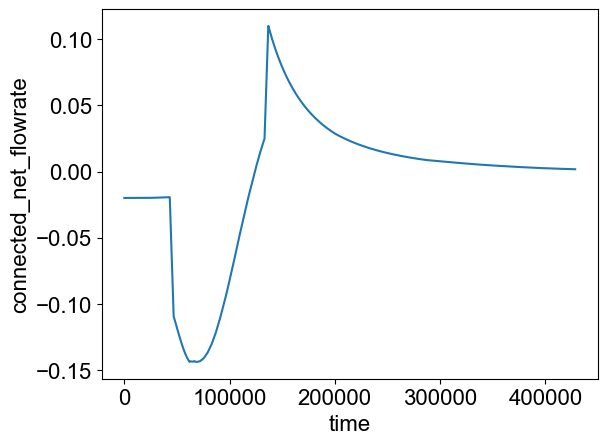

In [469]:
temp = results_dir['Anastomotic, unpressurized']
Q = temp['results']['flowrates']
h = temp['results']['water_depths']
v = temp['results']['velocities']
inflow = temp['input_data']['inflow_boundary']
for nodes, flow in inflow.items():
    t_r = flow['time']
    r = flow['flow'] * len(nodes)
nodes = temp['input_data']['nodes']
edges = temp['input_data']['edges']
geometry = temp['input_data']['cn_geometry']
edge_lookup = {
    tuple(sorted((row.from_id, row.to_id))): i
    for i, row in edges.iterrows()
}

order = [
    edge_lookup[tuple(sorted(conn))]
    for conn in geometry['throat.conns']
]

edges_ordered = edges.iloc[order].reset_index(drop=True)
obs_df = temp['obs_df']
spring_flow = obs_df[obs_df.node == temp['input_data']['outlets'][0]]
r_interp = np.interp(spring_flow.time, t_r, r)
dS = spring_flow.connected_net_flowrate - r_interp
total_spring_V = spring.calculate_volume(spring_flow.time, spring_flow.connected_net_flowrate)
total_recharge_V = spring.calculate_volume(spring_flow.time, r_interp)
recession_coeffs = spring.calculate_recession_coefficients(spring_flow.time, spring_flow.connected_net_flowrate)
peak_time = spring_flow[spring_flow.connected_net_flowrate == spring_flow.connected_net_flowrate.max()]['time'].values[0]
peak_idx = np.where(temp['results']['time'] >= peak_time)[0][0]
rising_idx = peak_idx - 500
tail_idx = peak_idx + 400
network = OKN(nodes = nodes, edges = edges_ordered, geometry = geometry)
network.load_cave_data()
network.extract_boundary_nodes()
volume = network.calculate_network_volume()
idx_to_plot = rising_idx
ax, lc, sc, cbar = network.plot_network_flow(np.abs(v[idx_to_plot])/np.abs(v).max(), h[idx_to_plot], vmin_q = 0, vmax_q = 0.1,  hide_nodes = True, palette = 'viridis', show_grid = False)
plt.xlabel("UTME")
plt.ylabel("UTMN")
plt.title("Unpressurized flow")

cbar.set_label(r"$v/v_{max}$")
plt.figure()
sns.lineplot(x = spring_flow.time, y = dS)
# plt.title(f"Spring V=  {total_spring_V:.2f}, Recharge V= {total_recharge_V:.2f}, conduit volume = {volume:.2f}, Q = {Q[peak_idx]:.2f},")



C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\3106795119.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\3106795119.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start


([], [])

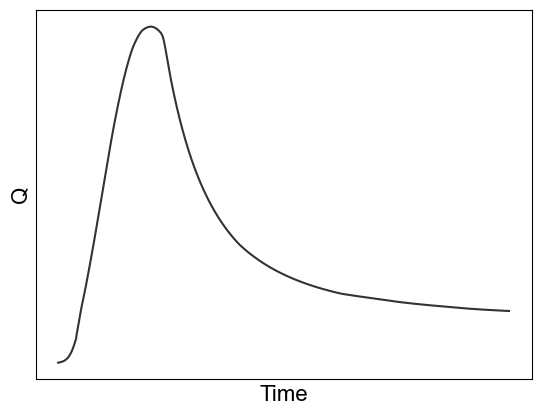

In [235]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16 
data = results_dir['Anastomotic, unpressurized']
results = data['results']
input_data = data['input_data']
obs_df = data['obs_df']
outlet_node = input_data['outlets'][0]
baseflow = data['baseflow']
for nodes, flow in input_data['inflow_boundary'].items():
    recharge_pulse_t_start = flow['time'][np.where(flow['flow'] * len(nodes) > baseflow)[0][0]]
    max_recharge = np.max(flow['flow'] * len(nodes))
    t_r = flow['time']
    r = flow['flow'] * len(nodes)
spring_data = obs_df[obs_df.node == outlet_node]
spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start
sns.lineplot(spring_data[spring_data['t_norm'] >= 0], 
                x= 't_norm', y = 'connected_net_flowrate',
                 color = 'black', alpha = 0.8)
plt.xlabel("Time")
plt.ylabel("Q")
plt.xticks([])
plt.yticks([])


C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\77915181.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\77915181.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['Q_norm'] = spring_data['connected_net_flowrate'] / max_recharge
C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\77915181.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of

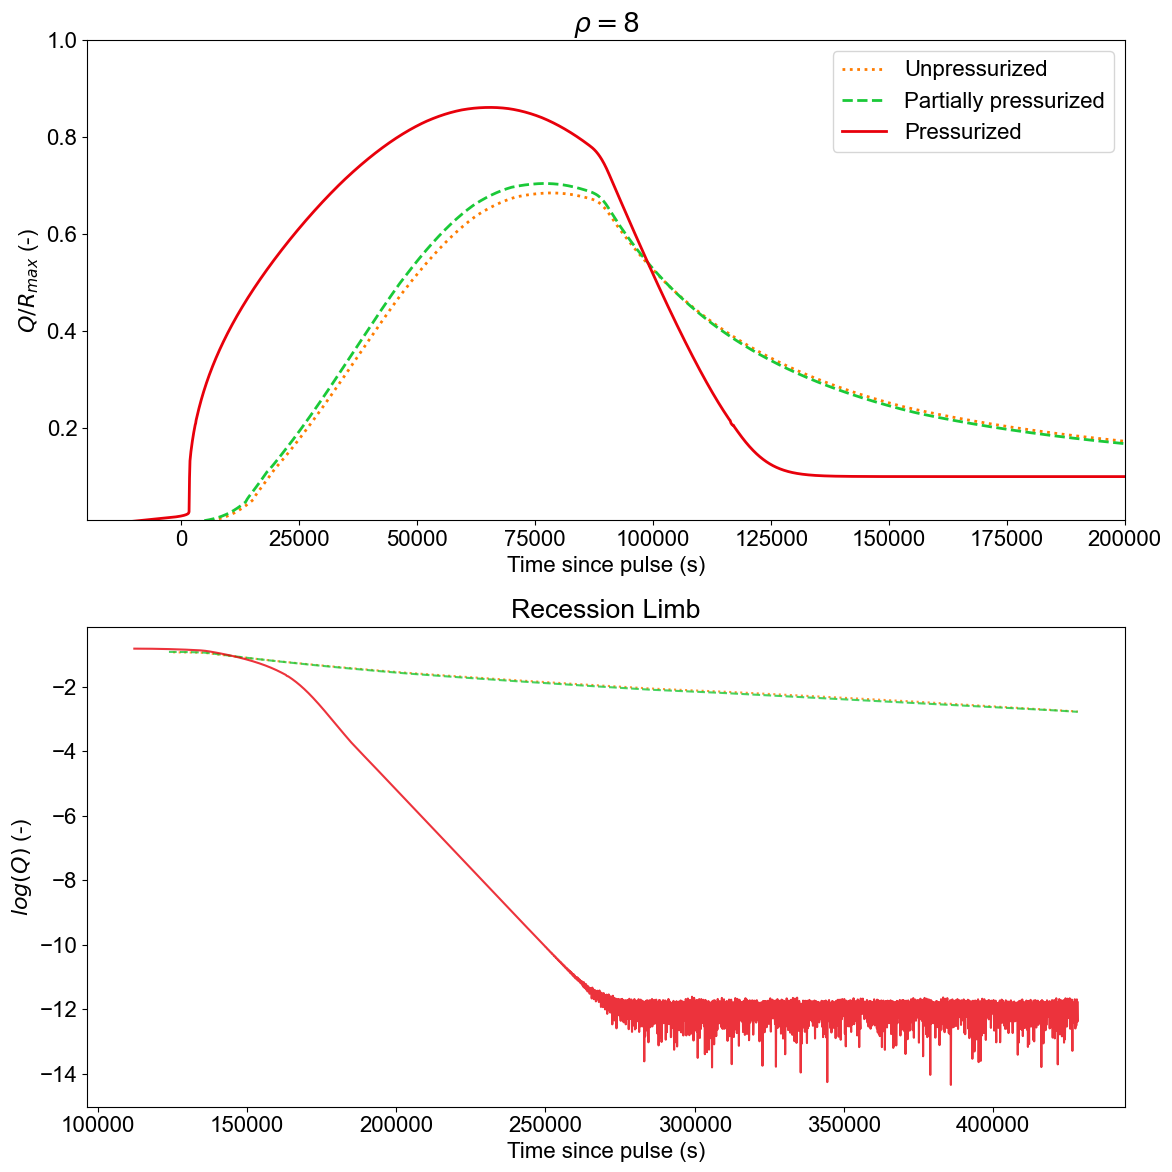

In [412]:
fig, ax = plt.subplots(2,1, figsize = (12,12))
selected_names = {
#     'Low anastomotic, unpressurized' : r'$\rho=$ 0',
# 'Low anastomotic, partially pressurized' : r'$\rho=$ 0',
# 'Low anastomotic, pressurized' : r'$\rho=$ 0',
# 'Anastomotic density 1, unpressurized' : r'$\rho=$ 1',
# 'Anastomotic density 1, partially pressurized' : r'$\rho=$ 1',
# 'Anastomotic density 1, pressurized' : r'$\rho=$ 1',
# 'Anastomotic density 1.5, unpressurized' : r'$\rho=$ 1.5',
# 'Anastomotic density 1.5, partially pressurized' : r'$\rho=$ 1.5',
# 'Anastomotic density 1.5, pressurized' : r'$\rho=$ 1.5',
# 'Anastomotic density 2, unpressurized' : 'Unpressurized',
# 'Anastomotic density 2, partially pressurized' : 'Partially pressurized',
# 'Anastomotic density 2, pressurized' : 'Pressurized',
# 'Anastomotic density 2.5, unpressurized' : r'$\rho=$ 2.5',
# 'Anastomotic density 2.5, partially pressurized' : r'$\rho=$ 2.5',
# 'Anastomotic density 2.5, pressurized' : r'$\rho=$ 2.5',
# 'Anastomotic density 3, unpressurized' : r'$\rho=$ 3',
# 'Anastomotic density 3, partially pressurized' : r'$\rho=$ 3',
# 'Anastomotic density 3, pressurized' : r'$\rho=$ 3',
# 'Anastomotic density 5, unpressurized' : r'$\rho=$ 5',
# 'Anastomotic density 5, partially pressurized' : r'$\rho=$ 5',
# 'Anastomotic density 5, pressurized' : r'$\rho=$ 5',
# 'Anastomotic density 6, unpressurized' : r'$\rho=$ 6',
# 'Anastomotic density 6, partially pressurized' : r'$\rho=$ 6',
# 'Anastomotic density 6, pressurized' : r'$\rho=$ 6',
# 'Anastomotic density 7, unpressurized' : r'$\rho=$ 7',
# 'Anastomotic density 7, partially pressurized' : r'$\rho=$ 7',
# 'Anastomotic density 7, pressurized' : r'$\rho=$ 7',
# 'Anastomotic 2, unpressurized' : r'$\rho=$ 7.5',
# 'Anastomotic 2, partially pressurized' : r'$\rho=$ 7.5',
# 'Anastomotic 2, pressurized' : r'$\rho=$ 7.5',

'Anastomotic, unpressurized' : 'Unpressurized',
'Anastomotic, partially pressurized' : 'Partially pressurized',
'Anastomotic, pressurized' : 'Pressurized',



# 'Branching network, unpressurized' : 'Branching network',
# 'Branching network, partially pressurized' : 'Branching network',
# 'Branching network, pressurized' : 'Branching network',
# 'Single conduit, unpressurized' : 'Single conduit',
# 'Single conduit, pressurized' : 'Single conduit',

# 'Single conduit, partially pressurized' : 'Single conduit',


}
i = 1
for name, label in selected_names.items():
    data = results_dir[name]
    results = data['results']
    input_data = data['input_data']
    obs_df = data['obs_df']
    outlet_node = input_data['outlets'][0]
    baseflow = data['baseflow']
    for nodes, flow in input_data['inflow_boundary'].items():
        recharge_pulse_t_start = flow['time'][np.where(flow['flow'] * len(nodes) > baseflow)[0][0]]
        max_recharge = np.max(flow['flow'] * len(nodes))
        t_r = flow['time']
        r = flow['flow'] * len(nodes)
        t_max_r = t_r[r==r.max()][0]

    spring_data = obs_df[obs_df.node == outlet_node]
    spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
    spring_data['Q_norm'] = spring_data['connected_net_flowrate'] / max_recharge
    spring_data['log_Q'] = np.log10(spring_data['Q_minus_bf'] + 1e-12)
    spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start

    peak_time = spring_data[spring_data.connected_net_flowrate == spring_data.connected_net_flowrate.max()]['time'].values[0]
    spring_data['time_since_peak'] = spring_data['time'] - peak_time
    r_interp = np.interp(spring_data.time, t_r, r)
    spring_data['dS'] = r_interp - spring_data.connected_net_flowrate.values
    spring_data['dS_norm'] = spring_data['dS'] / baseflow
    total_spring_V = spring.calculate_volume(spring_data.time, spring_data.connected_net_flowrate)
    total_recharge_V = spring.calculate_volume(spring_data.time, r_interp)
    recession_coeffs = spring.calculate_recession_coefficients(spring_data.time, spring_data.connected_net_flowrate, n_coeffs = 2)
    Q_width = spring.calculate_pulse_width(spring_data.time, spring_data.Q_minus_bf, threshold = 0.11)
    dS_width = spring.calculate_pulse_width(spring_data.time, spring_data.dS)
    r_width = spring.calculate_pulse_width(spring_data.time, r_interp, threshold = 0.15)
    network_metrics.loc[network_metrics['run'] == name, 'slope_recession_0'] = recession_coeffs[0][0] * -1
    network_metrics.loc[network_metrics['run'] == name, 'slope_recession_1'] = recession_coeffs[0][1] * -1

    network_metrics.loc[network_metrics['run'] == name, 'Q_peak'] = spring_data.connected_net_flowrate.max()
    network_metrics.loc[network_metrics['run'] == name, 'Q_peak_norm'] = spring_data.Q_norm.max()
    network_metrics.loc[network_metrics['run'] == name, 'V_spring/V_R'] = total_spring_V / total_recharge_V
    network_metrics.loc[network_metrics['run'] == name, 'Q_width'] = Q_width
    network_metrics.loc[network_metrics['run'] == name, 'dS_width'] = dS_width
    network_metrics.loc[network_metrics['run'] == name, 'Q_width_norm'] = Q_width/r_width
    network_metrics.loc[network_metrics['run'] == name, 'dS_width_norm'] = dS_width/r_width
    network_metrics.loc[network_metrics['run'] == name, 'peak_lag'] = peak_time - t_max_r
    network_metrics.loc[network_metrics['run'] == name, 'peak_lag_norm'] = (peak_time - t_max_r)/r_width

    if 'partially pressurized' in name:
        linestyle = '--'
    elif 'unpressurized' in name:
        linestyle = ':'
    else:
        linestyle = '-'
        # continue
    # if 'Anastomotic density 3' in name:
    #     color = 'red'
    # elif 'Anastomotic 2' in name:
    #     color = 'green'
    # elif 'Anastomotic' in name:
    #     color = 'blue'
    # elif 'Low anastomotic' in name:
    #     color = 'orange'
    # elif 'Branching network' in name:
    #     color = 'red'
    # elif 'Single conduit' in name:
    #     color = 'purple'
    colors = sns.color_palette('bright', n_colors= len(selected_names) +1 
    )
    sns.lineplot(spring_data, 
                 x= 't_norm', y = 'Q_norm', 
                 linestyle = linestyle, color = colors[i], ax = ax[0],  label = label, linewidth = 2)
    sns.lineplot(spring_data[spring_data['time'] > peak_time], 
                 x= 'time', y = 'log_Q', 
                 linestyle = linestyle, color = colors[i], ax = ax[1],  label = label,alpha = 0.8)
   
    # sns.lineplot(spring_data[spring_data['t_norm'] >= -40000], x = 't_norm', y = 'dS_norm', linestyle = linestyle, color = colors[i], ax = ax[1], alpha = 0.8)
    i+=1
    # sns.lineplot(spring_data[spring_data.time > peak_time], x = 'time_since_peak', y = 'log_Q', label = name, linestyle = linestyle, color = color, ax = ax[2], alpha = 0.8)
ax[0].legend(loc = 'upper right',)
ax[1].get_legend().remove()

# ax[0].set_xscale('log')
# ax[0].set_yscale('log')
ax[0].set_ylim(1e-2,1)
# ax[0].set_xscale('log')
ax[0].set_xlim(-2e4, 2e5)
# ax[1].set_xlim(1e5,)

ax[0].set_title(r"$\rho = 8$")
ax[1].set_title("Recession Limb")

ax[0].set_ylabel(r"$Q/R_{max}$ (-)", rotation = 90)
ax[0].set_xlabel(r"Time since pulse (s)"
, rotation = 0)
# ax[1].set_ylabel(r"$\dot{S}^*$ (-)", rotation = 90)
ax[1].set_ylabel(r"$log(Q)$ (-)", rotation = 90)

ax[1].set_xlabel(r"Time since pulse (s)", rotation = 0)
plt.tight_layout()

Text(0.5, 0.98, 'Reservoir Exchange and Head, $\\eta = 0.5$')

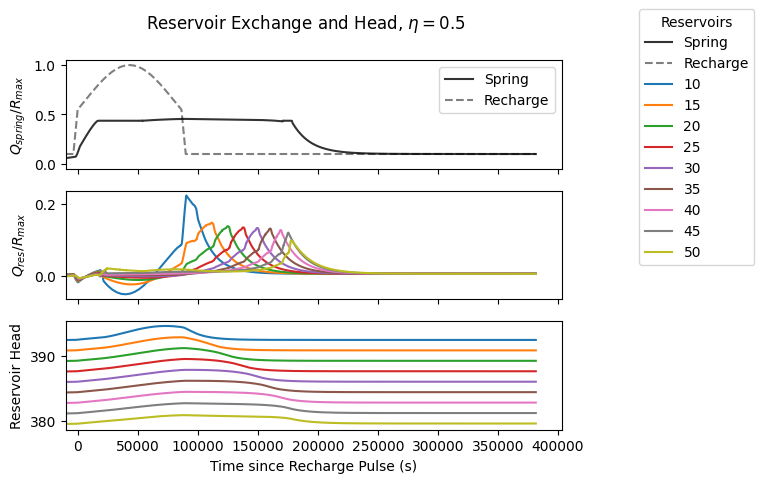

In [ ]:
fig, ax = plt.subplots(3,1, sharex = True)
alphas = {list(input_data['reservoirs'].keys())[i]: 0.1 * i for i in range(len(input_data['reservoirs']))}
sns.lineplot(spring_data ,
                x= 't_norm', y = 'Q_norm', linestyle = '-', color = 'black', label = "Spring",
                ax = ax[0], alpha = 0.8)
sns.lineplot( x = t_r - recharge_pulse_t_start, y = R/max_recharge, ax = ax[0], alpha = 0.5, color = 'black', linestyle = '--', label = "Recharge")
for reservoir, data in input_data['reservoirs'].items():
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'reservoir_head', ax = ax[2])
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'exchange_norm', ax = ax[1], label = reservoir)
fig.legend(
    title='Reservoirs',
    bbox_to_anchor=(1.01, 1.0),
    loc='upper left'
)
ax[0].set_ylabel(r"$Q_{spring}/R_{max}$", rotation = 90)
ax[1].get_legend().remove()
ax[1].set_ylabel(r"$Q_{res}/R_{max}$", rotation = 90)
ax[2].set_ylabel("Reservoir Head", rotation = 90)
ax[2].set_xlabel("Time since Recharge Pulse (s)", rotation = 0)
plt.xlim(-10000)
plt.suptitle(r"Reservoir Exchange and Head, $\eta = 0.5$")

In [ ]:
network_metrics.sort_values('k_mean')                 

,run,alpha,beta,tortuosity,orientation_entropy,k_mean,Q_peak,V_spring/V_R,slope_recession,hydraulic_regime,network,Q_peak_norm,Q_width,dS_width,Q_width_norm,dS_width_norm,peak_lag
38,"Single conduit, unpressurized",0.000000,0.500000,1.000000,-0.000000,1.000000,NaN,NaN,NaN,unpressurized,Single conduit,NaN,NaN,NaN,NaN,NaN,NaN
36,"Single conduit, pressurized",0.000000,0.500000,1.000000,-0.000000,1.000000,NaN,NaN,NaN,pressurized,Single conduit,NaN,NaN,NaN,NaN,NaN,NaN
37,"Single conduit, partially pressurized",0.000000,0.500000,1.000000,-0.000000,1.000000,NaN,NaN,NaN,partially pressurized,Single conduit,NaN,NaN,NaN,NaN,NaN,NaN
30,"Low anastomotic, pressurized",0.000000,1.250000,1.309145,0.234374,1.666667,0.188994,0.991519,0.000010,pressurized,Low anastomotic,0.944971,147100.622524,148600.622524,1.586846,1.603027,13900.622524
32,"Low anastomotic, unpressurized",0.000000,1.250000,1.309145,0.234374,1.666667,0.197373,0.975122,0.000011,unpressurized,Low anastomotic,0.986864,149800.002563,159200.002563,1.617711,1.719222,6800.002563
31,"Low anastomotic, partially pressurized",0.000000,1.250000,1.309145,0.234374,1.666667,0.197691,0.976324,0.000011,partially pressurized,Low anastomotic,0.988453,149000.600850,158000.600850,1.607342,1.704429,6300.600850
34,"Branching network, partially pressurized",0.000000,0.857143,1.000000,0.371049,1.714286,NaN,NaN,NaN,partially pressurized,Branching network,NaN,NaN,NaN,NaN,NaN,NaN
35,"Branching network, unpressurized",0.000000,0.857143,1.000000,0.371049,1.714286,NaN,NaN,NaN,unpressurized,Branching network,NaN,NaN,NaN,NaN,NaN,NaN
33,"Branching network, pressurized",0.000000,0.857143,1.000000,0.371049,1.714286,NaN,NaN,NaN,pressurized,Branching network,NaN,NaN,NaN,NaN,NaN,NaN
24,"Anastomotic density 6, pressurized",0.029101,5.571429,1.097957,0.350987,2.689655,0.155056,0.964021,0.000010,pressurized,Anastomotic density 6,0.775278,189300.644928,191600.644928,2.042078,2.066889,26500.644928


In [385]:
recession_coeffs

(array([-1.44037309e-05, -2.61105487e-06]),
 array([123800.47493852, 223357.09965534, 428300.47493852]))

Text(0, 0.5, '$\\tau_{Q}/\\tau_R $')

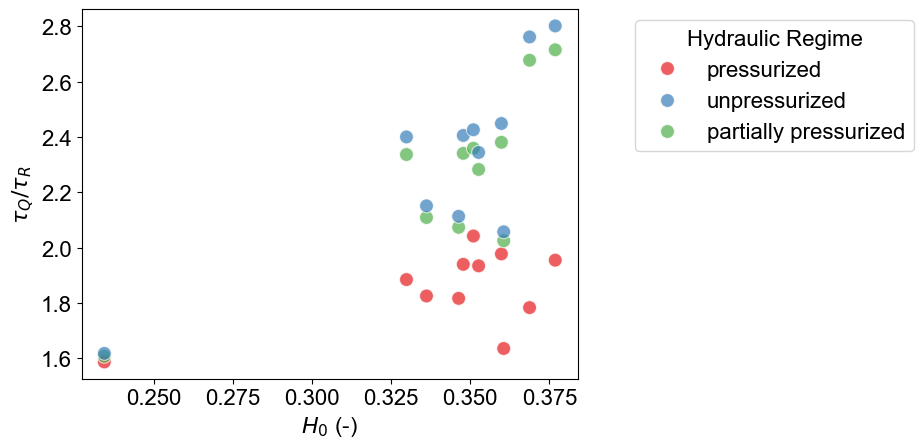

In [407]:
sns.scatterplot(network_metrics, x= 'orientation_entropy', y = 'Q_width_norm', hue = 'hydraulic_regime', s = 100,  alpha = 0.7, palette = 'Set1')
plt.legend(title = "Hydraulic Regime", loc = 'upper right', bbox_to_anchor=(1.7, 1))
plt.xlabel(r"$H_0$ (-)", rotation = 0)
plt.ylabel(r"$\tau_{Q}/\tau_R $", rotation = 90)


# Transport

In [ ]:
transport_dir = {
    'Anastomotic pressurized' : 'transport/single_pulse_1/high_anastomotic/pressurized/no_reservoir',
    'Anastomotic 2 pressurized' : 'transport/single_pulse_1/anastomotic_2/pressurized/no_reservoir',
    'Low anastomotic pressurized' : 'transport/single_pulse_1/low_anastomotic/pressurized/no_reservoir',
    'Branching network pressurized' : 'transport/single_pulse_1/branching_straight_network/pressurized/no_reservoir',
    'Single conduit pressurized' : 'transport/single_pulse_1/1D_conduit/pressurized/no_reservoir',

    'Anastomotic unpressurized' : 'transport/single_pulse/high_anastomotic/unpressurized/no_reservoir',
    'Anastomotic 2 unpressurized' : 'transport/single_pulse/anastomotic_2/unpressurized/no_reservoir',
    'Low anastomotic unpressurized' : 'transport/single_pulse/low_anastomotic/unpressurized/no_reservoir',
    'Branching network unpressurized' : 'transport/single_pulse/branching_straight_network/unpressurized/no_reservoir',
    'Single conduit unpressurized' : 'transport/single_pulse/1D_conduit/unpressurized/no_reservoir',

}

In [159]:
# transport_dir = {
#     'Anastomotic pressurized' : 'transport/high_anastomotic/d=0.1/no_reservoir',
#     'Anastomotic unpressurized' : 'transport/high_anastomotic/d=1.0/no_reservoir',
#     'Anastomotic partially pressurized' : 'transport/high_anastomotic/d=0.5/no_reservoir',
#     'Anastomotic 2 pressurized' : 'transport/anastomotic_2/d=0.1/no_reservoir',
#     'Anastomotic 2, partially pressurized' : 'transport/anastomotic_2/d=0.5/no_reservoir',
#     'Anastomotic 2, unpressurized' : 'transport/anastomotic_2/d=1.0/no_reservoir',

#     'Low anastomotic pressurized' : 'transport/low_anastomotic/d=0.1/no_reservoir',
#     'Low anastomotic, partially pressurized' : 'transport/low_anastomotic/d=0.5/no_reservoir',
#     'Low anastomotic, unpressurized' : 'transport/low_anastomotic/d=1/no_reservoir',
#     'Branching network, partially pressurized' : 'transport/branching_straight_network/d=0.5/no_reservoir',
#     'Branching network, pressurized' : 'transport/branching_straight_network/d=0.1/no_reservoir',
#     'Branching network, unpressurized' : 'transport/branching_straight_network/d=1.0/no_reservoir',

# }



transport_results = {}

for name, path in transport_dir.items():
    results, input_data, obs_df = load_data(path)
    transport_results[name] = {
        'results' : results,
        'input_data' : input_data,
        'obs_df' : obs_df
    }
    if 'pulse_only' in path:
        transport_results[name]['baseflow'] = 0
    else:
        transport_results[name]['baseflow'] = 0.02


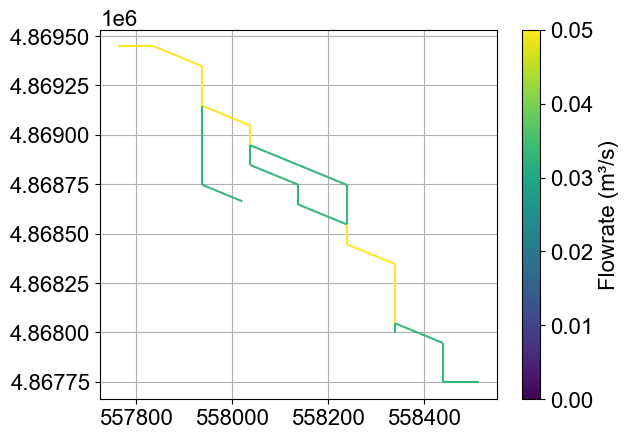

In [339]:
temp = transport_results['Low anastomotic pressurized']
Q = temp['results']['flowrates']
h = temp['results']['water_depths']
inflow = temp['input_data']['inflow_boundary']

nodes = temp['input_data']['nodes']
edges = temp['input_data']['edges']
geometry = temp['input_data']['cn_geometry']
edge_lookup = {
    tuple(sorted((row.from_id, row.to_id))): i
    for i, row in edges.iterrows()
}

order = [
    edge_lookup[tuple(sorted(conn))]
    for conn in geometry['throat.conns']
]
edges_ordered = edges.iloc[order].reset_index(drop=True)
obs_df = temp['obs_df']
spring_flow = obs_df[obs_df.node == temp['input_data']['outlets'][0]]
network = OKN(nodes = nodes, edges = edges_ordered, geometry = geometry)
network.load_cave_data()
network.extract_boundary_nodes()
volume = network.calculate_network_volume()
lc, sc = network.plot_network_flow(np.abs(Q[4000]), h[4000], vmin_q = 0, vmax_q = 0.05, hide_nodes = True, palette = 'viridis')


<Axes: >

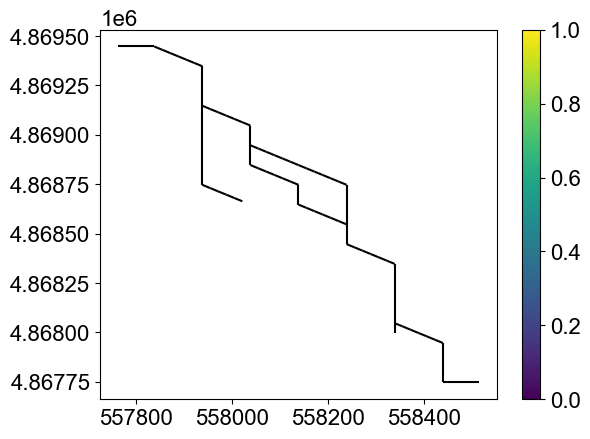

In [340]:
plot_2D_network(nodes, edges, grid = False)

C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2863360526.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_mass_input = np.trapz(C, t_conc)
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2863360526.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2863360526.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

([], [])

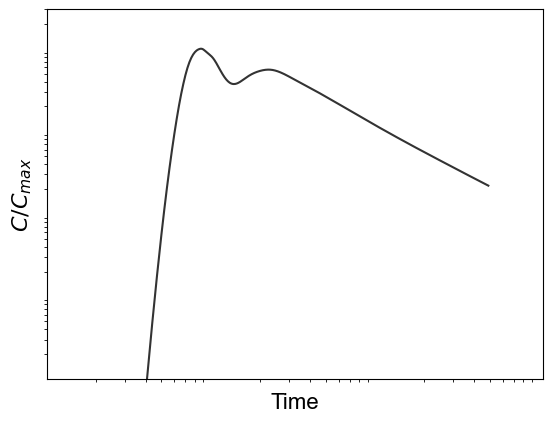

In [266]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16 
data = transport_results['Anastomotic 2 pressurized']
results = data['results']
input_data = data['input_data']
obs_df = data['obs_df']
outlet_node = input_data['outlets'][0]
baseflow = data['baseflow']

for nodes, conc in input_data['concentration_boundary'].items(): # REMEBMER THIS IS FOR MASS INPUT kg/s
    C = conc['concentration']
    t_conc = conc['time']
    total_mass_input = np.trapz(C, t_conc)
spring_data = obs_df[obs_df.node == outlet_node]
spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start
spring_data['C/C_max'] = spring_data.concentrations/np.max(spring_data.concentrations)
spring_data['t_norm'] = spring_data['time'] - t_conc[0]
sns.lineplot(spring_data[spring_data['t_norm'] >= 0], 
                x= 't_norm', y = 'C/C_max',
                 color = 'black', alpha = 0.8)
plt.xlabel("Time")
plt.ylabel(r"$C/C_{max}$")
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-4,3)
plt.xlim(1e3,)
plt.xticks([])
plt.yticks([])


Anastomotic pressurized
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Anastomotic 2 pressurized
[0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325 0.325
 0.325 0.325 0.325 0.325 0.325 0.

C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_mass_input = np.trapz(C, t_conc)
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['M/T'] = spring_data['concentrations'] * Q
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

Single conduit, unpressurized
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['M/T'] = spring_data['concentrations'] * Q
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring_data['C_norm'] = spring_data.concentrations/total_mass_input
C:\Users\huan1428\AppData\Local\Temp\ipykernel_12408\2420352258.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

Text(0.5, 0, 'Time since input (s)')

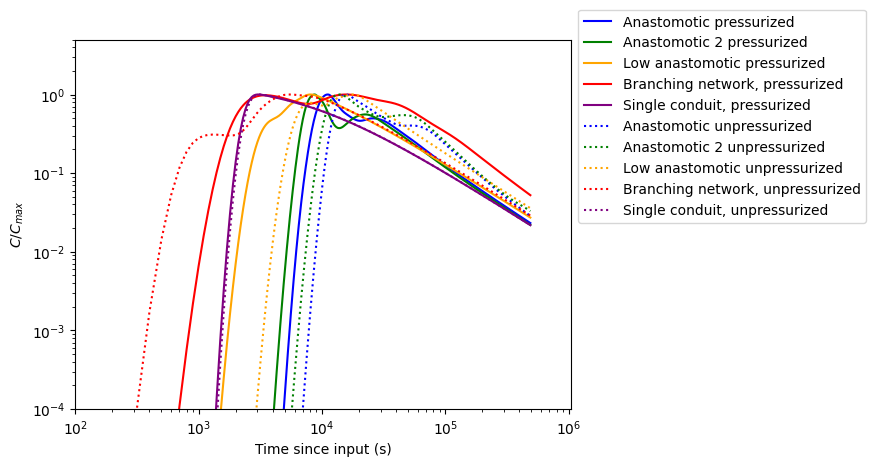

In [ ]:
fig, ax = plt.subplots()
for name, data in transport_results.items():
    print(name)
    results = data['results']
    input_data = data['input_data']
    obs_df = data['obs_df']
    outlet_node = input_data['outlets'][0]
    baseflow = data['baseflow']
    
    for nodes, flow in input_data['inflow_boundary'].items():
        Q = flow['flow']
    for nodes, conc in input_data['concentration_boundary'].items(): # REMEBMER THIS IS FOR MASS INPUT kg/s
        C = conc['concentration']
        t_conc = conc['time']
        total_mass_input = np.trapz(C, t_conc)
    spring_data = obs_df[obs_df.node == outlet_node]
    try:
        spring_data['M/T'] = spring_data['concentrations'] * Q
        spring_data['C_norm'] = spring_data.concentrations/total_mass_input
        spring_data['C/C_max'] = spring_data.concentrations/np.max(spring_data.concentrations)
        spring_data['t_norm'] = spring_data['time'] - t_conc[0]
    except KeyError:
        print(f"Error occurred while calculating M/T for {name}")
        continue
    if 'partially pressurized' in name:
        linestyle = '--'
    elif 'unpressurized' in name:
        linestyle = ':'
    else:
        linestyle = '-'
    if 'Anastomotic 2' in name:
        color = 'green'
    elif 'Anastomotic' in name:
        color = 'blue'
    elif 'Low anastomotic' in name:
        color = 'orange'
    elif 'Branching network' in name:
        color = 'red'
    elif 'Single conduit' in name:
        color = 'purple'
    sns.lineplot(spring_data, 
                    x= 't_norm', y = 'C/C_max', label = name, 
                    linestyle = linestyle, color = color, ax = ax)
    plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1.1))

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e2,)
plt.ylim(1e-4,5)
plt.ylabel(r"$C/C_{max} $", rotation = 90)
plt.xlabel(r"Time since input (s)", rotation = 0)

# Sensitivity Analysis

In [ ]:
gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_0',
'gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_0.5',
'gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_1',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_0',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_0.5',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_1',
'gaussian pulse, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_1',


SyntaxError: unterminated string literal (detected at line 1) (2615150296.py, line 1)

In [484]:
path_dir = {
    'C = 1e-2, eta = 0' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_0',
    'C = 1e-2, eta = 0.5' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_0.5',
    'C = 1e-2, eta = 1' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_1',

    'C = 1e-5, eta = 0' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_0',
    'C = 1e-5, eta = 0.5' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_0.5',
    'C = 1e-5, eta = 1' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_1',

    'high S_y, C = 1e-2, eta = 0' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_0',
    'high S_y, C = 1e-2, eta = 0.5' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_0.5',
    'high S_y, C = 1e-2, eta = 1' : 'sensitivity_conduit_recharge/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_1',

'gaussian pulse, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10,)/conduit_eta_1',

'gaussian pulse, C = 1e-5, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, C = 1e-5, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, C = 1e-5, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10,)/conduit_eta_1',

'gaussian pulse, high S_y, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, high S_y, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, high S_y, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10,)/conduit_eta_1',

'gaussian pulse, 3 reservoir, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_0',
'gaussian pulse, 3 reservoir, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_0.5',
'gaussian pulse, 3 reservoir, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_1',

'gaussian pulse, 3 reservoir, C = 1e-5, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10, 55, 30)/conduit_eta_0',
'gaussian pulse, 3 reservoir, C = 1e-5, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10, 55, 30)/conduit_eta_0.5',
'gaussian pulse, 3 reservoir, C = 1e-5, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_(10, 55, 30)/conduit_eta_1',

'gaussian pulse, 3 reservoir, high S_y, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_0',
'gaussian pulse, 3 reservoir, high S_y, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_0.5',
'gaussian pulse, 3 reservoir, high S_y, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.01/reservoirs_(10, 55, 30)/conduit_eta_1',

'gaussian pulse, 9 reservoir, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_9/conduit_eta_0',
'gaussian pulse, 9 reservoir, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_9/conduit_eta_0.5',
'gaussian pulse, 9 reservoir, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_9/conduit_eta_1',
'gaussian pulse, 5 reservoir, C = 1e-2, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_5/conduit_eta_0',
'gaussian pulse, 5 reservoir, C = 1e-2, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_5/conduit_eta_0.5',
'gaussian pulse, 5 reservoir, C = 1e-2, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.01/reservoirs_5/conduit_eta_1',

'gaussian pulse, 9 reservoir, C = 1e-5, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_9/conduit_eta_0',
'gaussian pulse, 9 reservoir, C = 1e-5, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_9/conduit_eta_0.5',
'gaussian pulse, 9 reservoir, C = 1e-5, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_9/conduit_eta_1',
'gaussian pulse, 5 reservoir, C = 1e-5, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_5/conduit_eta_0',
'gaussian pulse, 5 reservoir, C = 1e-5, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_5/conduit_eta_0.5',
'gaussian pulse, 5 reservoir, C = 1e-5, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_1e-05/reservoirs_5/conduit_eta_1',


'gaussian pulse, 9 reservoir, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_9/conduit_eta_0',
'gaussian pulse, 9 reservoir, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_9/conduit_eta_0.5',
'gaussian pulse, 9 reservoir, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_9/conduit_eta_1',
'gaussian pulse, 5 reservoir, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_5/conduit_eta_0',
'gaussian pulse, 5 reservoir, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_5/conduit_eta_0.5',
'gaussian pulse, 5 reservoir, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_5/conduit_eta_1',
'gaussian pulse, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.01/C_0.1/reservoirs_(10,)/conduit_eta_1',

'gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_0',
'gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_0.5',
'gaussian pulse, 9 reservoir, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_9/conduit_eta_1',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_0',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_0.5',
'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_5/conduit_eta_1',
'gaussian pulse, high S_y, C = 1e-1, eta = 0' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_0',
'gaussian pulse, high S_y, C = 1e-1, eta = 0.5' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_0.5',
'gaussian pulse, high S_y, C = 1e-1, eta = 1' : 'sensitivity_gaussian_high_flow/A_1000000.0/S_y_0.5/C_0.1/reservoirs_(10,)/conduit_eta_1',

}

sensitivity_dir = {}

for name, path in path_dir.items():
    try: 
        results, input_data, obs_df = load_data(path)
    except Exception as e:
        print(f"Error loading data for {name}: {e}")
        continue
    sensitivity_dir[name] = {
        'results' : results,
        'input_data' : input_data,
        'obs_df' : obs_df
    }
    

C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\1013332640.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoir_exchange['exchange_norm'] = reservoir_exchange['reservoir_exchange'] / max_recharge
C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\1013332640.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservoir_exchange['t_norm'] = reservoir_exchange['time'] - recharge_pulse_t_start
C:\Users\huan1428\AppData\Local\Temp\ipykernel_960\1013332640.py:94: SettingWithCopyWarning: 
A value is 

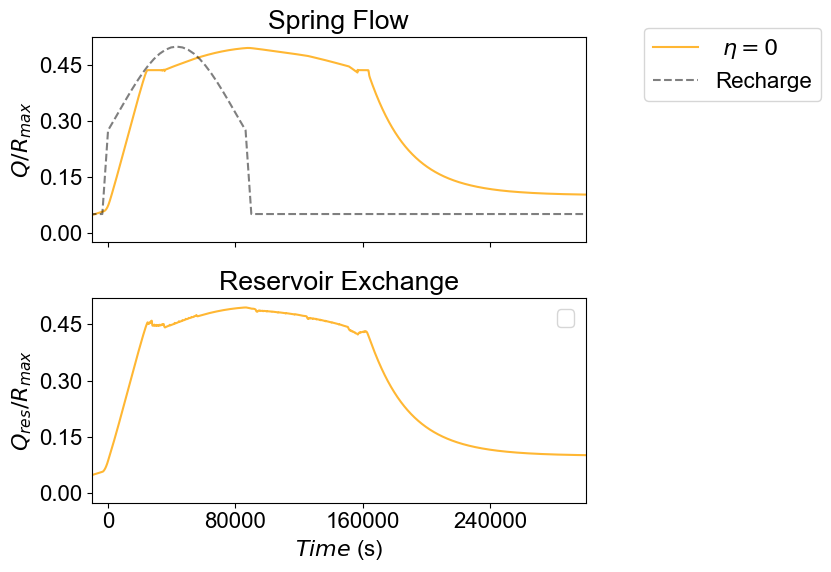

In [488]:
fig, ax = plt.subplots(2,1, figsize = (10,6), sharex = True)
from matplotlib.ticker import MaxNLocator

# C = 1e-2, eta = 0
# C = 1e-2, eta = 0.5
# C = 1e-2, eta = 1
# C = 1e-5, eta = 0
# C = 1e-5, eta = 0.5
# C = 1e-5, eta = 1
# high S_y, C = 1e-2, eta = 0
# high S_y, C = 1e-2, eta = 0.5
# high S_y, C = 1e-2, eta = 1'
# 'gaussian pulse, C = 1e-2, eta = 0'
# 'gaussian pulse, C = 1e-2, eta = 0.5'
# 'gaussian pulse, C = 1e-2, eta = 1'
# 'gaussian pulse, C = 1e-5, eta = 0'
# 'gaussian pulse, C = 1e-5, eta = 0.5'
# 'gaussian pulse, C = 1e-5, eta = 1'
# 'gaussian pulse, high S_y, C = 1e-2, eta = 0'
# 'gaussian pulse, high S_y, C = 1e-2, eta = 0.5'
# 'gaussian pulse, high S_y, C = 1e-2, eta = 1

selected_names = {
    # 'gaussian pulse, C = 1e-2, eta = 0' : r'$\eta = 0$',
    # 'gaussian pulse, C = 1e-5, eta = 0.5': r'low C, $\eta = 0.5$',
        # 'gaussian pulse, C = 1e-2, eta = 0': r'Single reservoir $\eta = 0$',
    # 'gaussian pulse, C = 1e-2, eta = 0.5': r'Single reservoir $\eta = 0.5$',
    # 'gaussian pulse, C = 1e-2, eta = 1': r'Single reservoir $\eta = 1$',
    # 'gaussian pulse, C = 1e-1, eta = 0': r'Single reservoir $\eta = 0$',
    # 'gaussian pulse, C = 1e-1, eta = 0.5': r'Single reservoir $\eta = 0.5$',
    # 'gaussian pulse, C = 1e-1, eta = 1': r'Single reservoir $\eta = 1$',
    # # 'gaussian pulse, 3 reservoir, C = 1e-2, eta = 0': r'$\eta = 0$',
    # 'gaussian pulse, 3 reservoir, C = 1e-2, eta = 0' : r'3 reservoirs $\eta = 0$',
    # 'gaussian pulse, 3 reservoir, C = 1e-2, eta = 0.5' : r'3 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 3 reservoir, C = 1e-2, eta = 1' : r'3 reservoirs $\eta = 1$',

        # 'gaussian pulse, 5 reservoir, C = 1e-2, eta = 0' : r'C = 1e-2, $\eta = 0$',
    # 'gaussian pulse, 5 reservoir, C = 1e-2, eta = 0.5' : r'5 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 5 reservoir, C = 1e-2, eta = 1' : r'C = 1e-2, $\eta = 1$',
    'gaussian pulse, 5 reservoir, C = 1e-1, eta = 0': r' $\eta = 0$',
    # 'gaussian pulse, 5 reservoir, C = 1e-1, eta = 0.5': r'5 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 5 reservoir, C = 1e-1, eta = 1': r' $\eta = 1$',

        # 'gaussian pulse, 5 reservoir, high S_y, C = 1e-2, eta = 0' : r'C = 1e-2, $\eta = 0$',
    # 'gaussian pulse, 5 reservoir, C = 1e-2, eta = 0.5' : r'5 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 5 reservoir, high S_y, C = 1e-2, eta = 1' : r'C = 1e-2, $\eta = 1$',
    # 'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 0': r'high S_y, $\eta = 0$',
    # # 'gaussian pulse, 5 reservoir, C = 1e-1, eta = 0.5': r'5 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 5 reservoir, high S_y, C = 1e-1, eta = 1': r'high S_y, $\eta = 1$',

    # 'gaussian pulse, 9 reservoir, C = 1e-2, eta = 0' : r'9 reservoirs $\eta = 0$',
    # 'gaussian pulse, 9 reservoir, C = 1e-2, eta = 0.5' : r'9 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 9 reservoir, C = 1e-2, eta = 1' : r'9 reservoirs $\eta = 1$',
        # 'gaussian pulse, 9 reservoir, C = 1e-1, eta = 0' : r'9 reservoirs $\eta = 0$',
    # 'gaussian pulse, 9 reservoir, C = 1e-1, eta = 0.5' : r'9 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 9 reservoir, C = 1e-1, eta = 1' : r'9 reservoirs $\eta = 1$',
        # 'gaussian pulse, 9 reservoir, C = 1e-5, eta = 0' : r'9 reservoirs $\eta = 0$',
    # 'gaussian pulse, 9 reservoir, C = 1e-5, eta = 0.5' : r'9 reservoirs $\eta = 0.5$',
    # 'gaussian pulse, 9 reservoir, C = 1e-5, eta = 1' : r'9 reservoirs $\eta = 1$',
    
    # 'gaussian pulse, C = 1e-5, eta = 1': r'$\eta = 1$',
# 'gaussian pulse, high S_y, C = 1e-2, eta = 0' : r'high $S_y$, $\eta = 0$',
# 'gaussian pulse, high S_y, C = 1e-2, eta = 0.5': r'high $S_y$, $\eta = 0.5$',
# 'gaussian pulse, high S_y, C = 1e-2, eta = 1': r'high $S_y$, $\eta = 1$',

}
for name, label in selected_names.items():
    data = sensitivity_dir[name]
    results = data['results']
    input_data = data['input_data']
    obs_df = data['obs_df']
    outlet_node = input_data['outlets'][0]
    for nodes, flow in input_data['inflow_boundary'].items():
        try:
            R =  flow['flow'] * len(nodes) 
        except IndexError:
            continue
        t_r = flow['time']
    for node, reservoir in input_data['reservoirs'].items():
        reservoir_R = reservoir['reservoir_recharge'][2]
        R += reservoir_R
    baseflow = R[0]
    recharge_pulse_t_start = flow['time'][np.where(R > baseflow)[0][0]]
    max_recharge = np.max(R)
    t_r_norm = t_r - recharge_pulse_t_start 
    spring_data = obs_df[obs_df.node == outlet_node]
    reservoir_exchange = obs_df[obs_df.node.isin(list(input_data['reservoirs'].keys()))]
    reservoir_exchange['exchange_norm'] = reservoir_exchange['reservoir_exchange'] / max_recharge
    reservoir_exchange['t_norm'] = reservoir_exchange['time'] - recharge_pulse_t_start
    total_res = reservoir_exchange.groupby('time')['reservoir_exchange'].sum().reset_index()
    total_res['exchange_norm'] = total_res['reservoir_exchange'] / max_recharge
    total_res['t_norm'] = total_res['time'] - recharge_pulse_t_start
    # spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
    spring_data['Q_norm'] = spring_data['connected_net_flowrate'] / max_recharge
    # spring_data['log_Q'] = np.log10(spring_data['Q_minus_bf'] + 1e-12)
    spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start
    if 'C = 1e-2' in name:
        linestyle = '--'
    elif 'C = 1e-1' in name:
        linestyle = '-'
    elif 'C = 1e-5' in name:
        linestyle = ':'
    if 'high S_y' in name:
        linestyle = '-.'
    if 'Single reservoir' in label:
        linestyle = '-'
    # elif '3 reservoir' in name:
    #     linestyle = '-.'
    # elif '5 reservoir' in name:
    #     linestyle = ':'
    # elif '9 reservoir' in name:
    #      linestyle = '--'
    if 'eta = 1' in name:
        color = 'green'
    elif 'eta = 0.5' in name:
        color = 'blue'
    elif 'eta = 0' in name:
        color = 'orange'
    # elif 'Branching network' in name:
    #     color = 'red'
    # elif 'Single conduit' in name:
    #     color = 'purple'
    alphas = {list(input_data['reservoirs'].keys())[i]: 0.1 * i for i in range(len(input_data['reservoirs']))}
    sns.lineplot(spring_data ,
                x= 't_norm', y = 'Q_norm', label = label, linestyle = linestyle, color = color,
                ax = ax[0], alpha = 0.8)
    sns.lineplot(total_res, x = 't_norm', y = 'exchange_norm', ax = ax[1], alpha = 0.8, color=color, linestyle=linestyle)
    # for node, reservoir in input_data['reservoirs'].items():
    #     sns.lineplot(reservoir_exchange[reservoir_exchange.node == node], x = 'time', y = 'exchange_norm', label = f"Reservoir {node}", ax = ax[1], alpha = alphas[node], color=color, linestyle=linestyle)
    if 'C = 1e-5' in name or 'high S_y' in name:
        continue
sns.lineplot(x = t_r_norm, y = R, ax = ax[0], alpha = 0.5, color = 'black', linestyle = '--', label = 'Recharge')

ax[0].legend(loc = 'upper right', bbox_to_anchor=(1.5, 1.1))
ax[1].legend(loc = 'upper right')

# plt.xscale('log')
# ax.set_yscale('log')
# twinx.invert_yaxis()
# ax.set_ylim(1e-3,)
ax[0].set_xlim(-1e4,3e5)
ax[1].set_xlim(-1e4,3e5)

ax[0].set_ylabel(r"$Q/R_{max}$", rotation = 90)
ax[0].set_xlabel(r"$Time$ (s)", rotation = 0)
ax[0].set_title("Spring Flow")
ax[1].set_title("Reservoir Exchange")
ax[1].set_ylabel(r"$Q_{res}/R_{max}$", rotation = 90)
ax[1].set_xlabel(r"$Time$ (s)", rotation = 0)
ax[0].xaxis.set_major_locator(MaxNLocator(5))
ax[0].yaxis.set_major_locator(MaxNLocator(5))
ax[1].xaxis.set_major_locator(MaxNLocator(5))
ax[1].yaxis.set_major_locator(MaxNLocator(5))
plt.tight_layout()


Text(0.5, 0.98, 'Reservoir Exchange and Head, $\\eta = 0.5$')

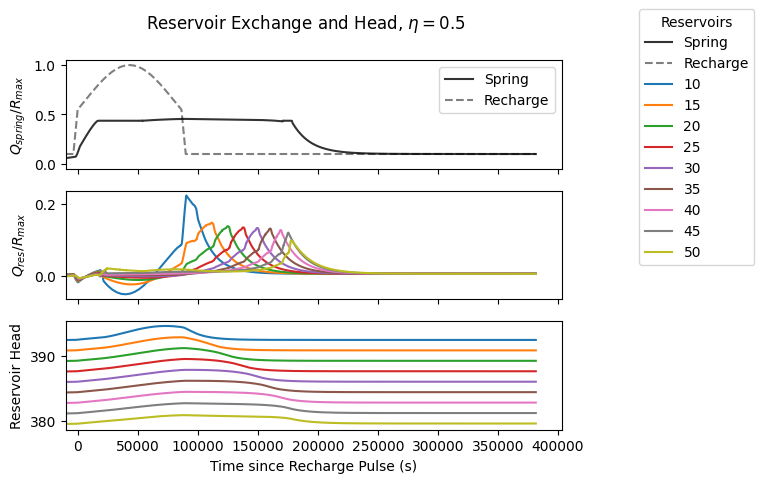

In [ ]:
fig, ax = plt.subplots(3,1, sharex = True)
alphas = {list(input_data['reservoirs'].keys())[i]: 0.1 * i for i in range(len(input_data['reservoirs']))}
sns.lineplot(spring_data ,
                x= 't_norm', y = 'Q_norm', linestyle = '-', color = 'black', label = "Spring",
                ax = ax[0], alpha = 0.8)
sns.lineplot( x = t_r - recharge_pulse_t_start, y = R/max_recharge, ax = ax[0], alpha = 0.5, color = 'black', linestyle = '--', label = "Recharge")
for reservoir, data in input_data['reservoirs'].items():
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'reservoir_head', ax = ax[2])
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'exchange_norm', ax = ax[1], label = reservoir)
fig.legend(
    title='Reservoirs',
    bbox_to_anchor=(1.01, 1.0),
    loc='upper left'
)
ax[0].set_ylabel(r"$Q_{spring}/R_{max}$", rotation = 90)
ax[1].get_legend().remove()
ax[1].set_ylabel(r"$Q_{res}/R_{max}$", rotation = 90)
ax[2].set_ylabel("Reservoir Head", rotation = 90)
ax[2].set_xlabel("Time since Recharge Pulse (s)", rotation = 0)
plt.xlim(-10000)
plt.suptitle(r"Reservoir Exchange and Head, $\eta = 0.5$")

Text(0.5, 0.98, 'Reservoir Exchange and Head, $\\eta = 0$')

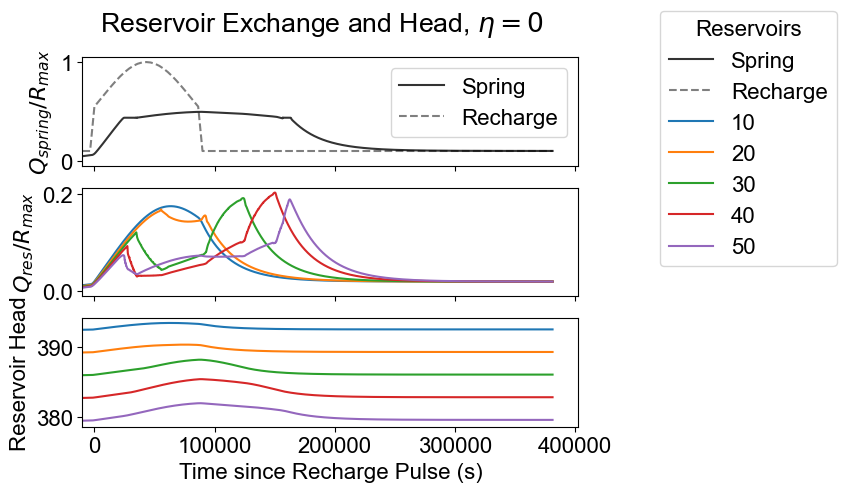

In [489]:
fig, ax = plt.subplots(3,1, sharex = True)
alphas = {list(input_data['reservoirs'].keys())[i]: 0.1 * i for i in range(len(input_data['reservoirs']))}
sns.lineplot(spring_data ,
                x= 't_norm', y = 'Q_norm', linestyle = '-', color = 'black', label = "Spring",
                ax = ax[0], alpha = 0.8)
sns.lineplot( x = t_r - recharge_pulse_t_start, y = R/max_recharge, ax = ax[0], alpha = 0.5, color = 'black', linestyle = '--', label = "Recharge")
for reservoir, data in input_data['reservoirs'].items():
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'reservoir_head', ax = ax[2])
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'exchange_norm', ax = ax[1], label = reservoir)
fig.legend(
    title='Reservoirs',
    bbox_to_anchor=(1.01, 1.0),
    loc='upper left'
)
ax[0].set_ylabel(r"$Q_{spring}/R_{max}$", rotation = 90)
ax[1].get_legend().remove()
ax[1].set_ylabel(r"$Q_{res}/R_{max}$", rotation = 90)
ax[2].set_ylabel("Reservoir Head", rotation = 90)
ax[2].set_xlabel("Time since Recharge Pulse (s)", rotation = 0)
plt.xlim(-10000)
plt.suptitle(r"Reservoir Exchange and Head, $\eta = 0$")

Text(0.5, 0.98, 'Reservoir Exchange and Head, $\\eta = 1$')

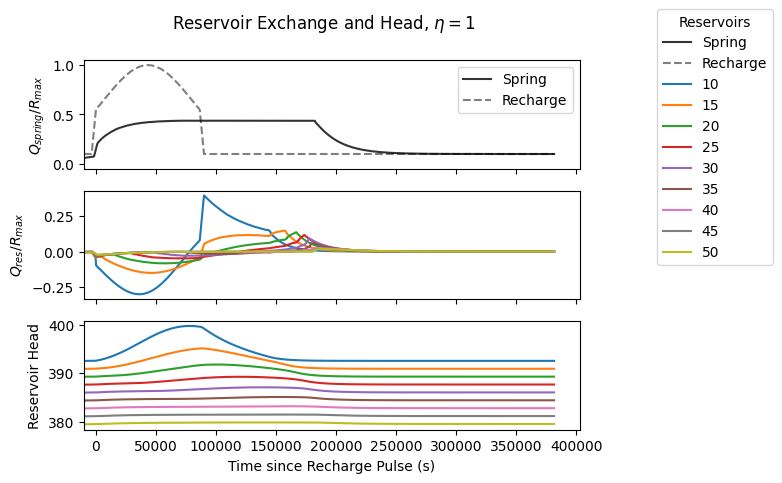

In [47]:
fig, ax = plt.subplots(3,1, sharex = True)
alphas = {list(input_data['reservoirs'].keys())[i]: 0.1 * i for i in range(len(input_data['reservoirs']))}
sns.lineplot(spring_data ,
                x= 't_norm', y = 'Q_norm', linestyle = '-', color = 'black', label = "Spring",
                ax = ax[0], alpha = 0.8)
sns.lineplot( x = t_r - recharge_pulse_t_start, y = R/max_recharge, ax = ax[0], alpha = 0.5, color = 'black', linestyle = '--', label = "Recharge")
for reservoir, data in input_data['reservoirs'].items():
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'reservoir_head', ax = ax[2])
    sns.lineplot(data=reservoir_exchange[reservoir_exchange.node == reservoir], x = 't_norm', y = 'exchange_norm', ax = ax[1], label = reservoir)
fig.legend(
    title='Reservoirs',
    bbox_to_anchor=(1.01, 1.0),
    loc='upper left'
)
ax[0].set_ylabel(r"$Q_{spring}/R_{max}$", rotation = 90)
ax[1].get_legend().remove()
ax[1].set_ylabel(r"$Q_{res}/R_{max}$", rotation = 90)
ax[2].set_ylabel("Reservoir Head", rotation = 90)
ax[2].set_xlabel("Time since Recharge Pulse (s)", rotation = 0)
plt.xlim(-10000)
plt.suptitle(r"Reservoir Exchange and Head, $\eta = 1$")

Text(0.5, 0, 'Time (s)')

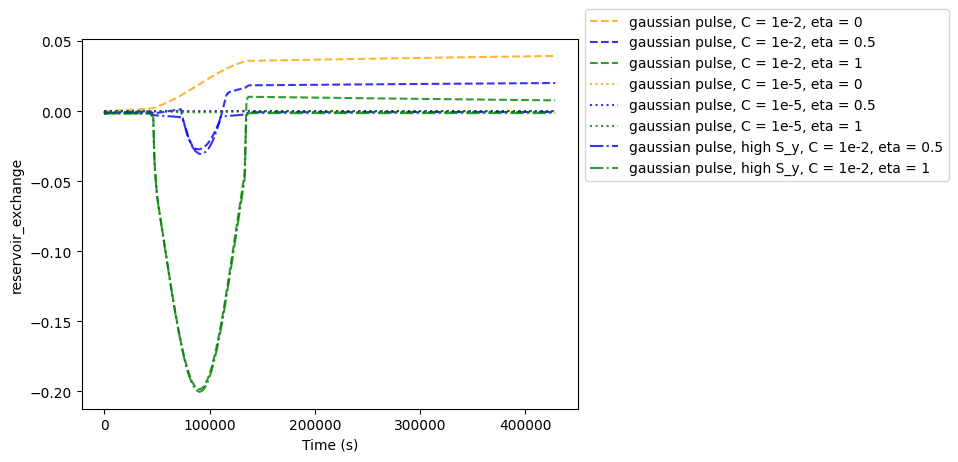

In [255]:
fig, ax = plt.subplots()
baseflow = 0.05
for name, data in sensitivity_dir.items():
    results = data['results']
    input_data = data['input_data']
    obs_df = data['obs_df']
    outlet_node = input_data['outlets'][0]
    for nodes, flow in input_data['inflow_boundary'].items():
        try:
            recharge_pulse_t_start = flow['time'][np.where(flow['flow'] * len(nodes) > baseflow)[0][0]]
        except IndexError:
            continue
        max_recharge = np.max(flow['flow'] * len(nodes))
        t_r = flow['time']
        r = flow['flow'] * len(nodes)
    spring_data = obs_df[obs_df.node == outlet_node]
    reservoir_exchange = obs_df[obs_df.node == list(input_data['reservoirs'].keys())[0]]
    # spring_data['Q_minus_bf'] = spring_data['connected_net_flowrate'] - baseflow
    # spring_data['Q_norm'] = spring_data['Q_minus_bf'] / max_recharge
    # spring_data['log_Q'] = np.log10(spring_data['Q_minus_bf'] + 1e-12)
    # spring_data['t_norm'] = spring_data['time'] - recharge_pulse_t_start
    if 'C = 1e-2' in name:
        linestyle = '--'
    elif 'C = 1e-5' in name:
        linestyle = ':'

    if 'high S_y' in name:
        linestyle = '-.'
    # else:
    #     linestyle = '-'
    if 'eta = 1' in name:
        color = 'green'
    elif 'eta = 0.5' in name:
        color = 'blue'
    elif 'eta = 0' in name:
        color = 'orange'
    if 'gaussian' not in name:
        continue
    sns.lineplot(reservoir_exchange ,
                 x= 'time', y = 'reservoir_exchange', label = name, color = color, linestyle = linestyle,
                  ax = ax, alpha = 0.8)
plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1.1))

# plt.xscale('log')
# plt.yscale('log')
# plt.ylabel(r"$Q/R_{max}$", rotation = 90)
plt.xlabel(r"Time (s)", rotation = 0)

In [65]:
#visualization
def find_free_port(start=8050):
    port = start
    while True:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
            try:
                sock.bind(("0.0.0.0", port))
                return port
            except OSError:
                port += 1

viewer_port = find_free_port(8050)
data = results_dir['Branching network no reservoir']
launch_openkarst_viewer(data['results'], data['input_data']['cn_geometry'], data['obs_df'], port=viewer_port)
